Hands-On Lab: Sprint 1 Kickoff & Baseline       
● Step 1: Complete Sprint 1 planning: confirm the goal and select the first backlog tasks.      
● Step 2: Finalize the project dataset and complete a brief EDA in the project notebook.        
● Step 3: Train a simple baseline model (e.g. logistic/linear regression from Week 3) and record its metric.        
● Step 4: Commit the baseline notebook to a feature branch and open a draft pull request.       
● Step 5: In Markdown, state the baseline score every later model must beat.        

#### Load, Clean & split data:

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split , cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,recall_score, classification_report, confusion_matrix, f1_score


In [20]:
df = pd.read_csv(r"C:\Users\Masters Computer\Desktop\VScode_For_ Python\internship\week6\Sprint1 practice\Data\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = df.drop(columns = 'customerID')

In [21]:
print (df.shape,"\n")

print ("Null values: \n", df.isna().sum(),"\n")

print("duplicates :",df.duplicated().sum(),"\n")

print ("Information:")
df.info()

(7043, 20) 

Null values: 
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64 

duplicates : 22 

Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleL

In [22]:
print (df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [23]:
X = df.drop(columns ='Churn')
y = df['Churn']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify= y)

print(y_train.unique(),"\n")
print(y_train.value_counts(),"\n")
print(y_train.dtype)

<StringArray>
['No', 'Yes']
Length: 2, dtype: str 

Churn
No     4139
Yes    1495
Name: count, dtype: int64 

str


In [24]:
categorical_cols = X_train.select_dtypes(include=['str']).columns.tolist()

numerical_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

print("categorical columns name: ")
print(categorical_cols)

print("\nnumerical columns name: ")
print(numerical_cols)

categorical columns name: 
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']

numerical columns name: 
['SeniorCitizen', 'tenure', 'MonthlyCharges']


#### Brief EDA

##### Target class (Churn) distribution:

In [25]:
print(df["Churn"].value_counts(),"\n")
print(df["Churn"].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64 

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


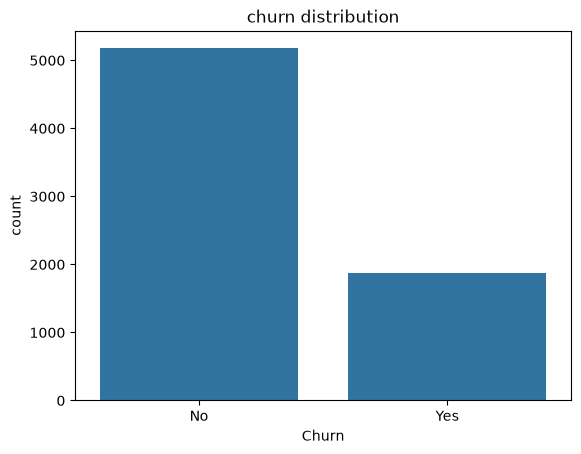

In [26]:
sns.countplot(data=df, x="Churn")
plt.title('churn distribution')
plt.show()

The dataset is moderately imbalanced, with substantially more non-churn customers than churn customers.     
 Therefore, accuracy alone may not be sufficient, and F1 score is also considered during model evaluation.  

##### Numerical features distributions:

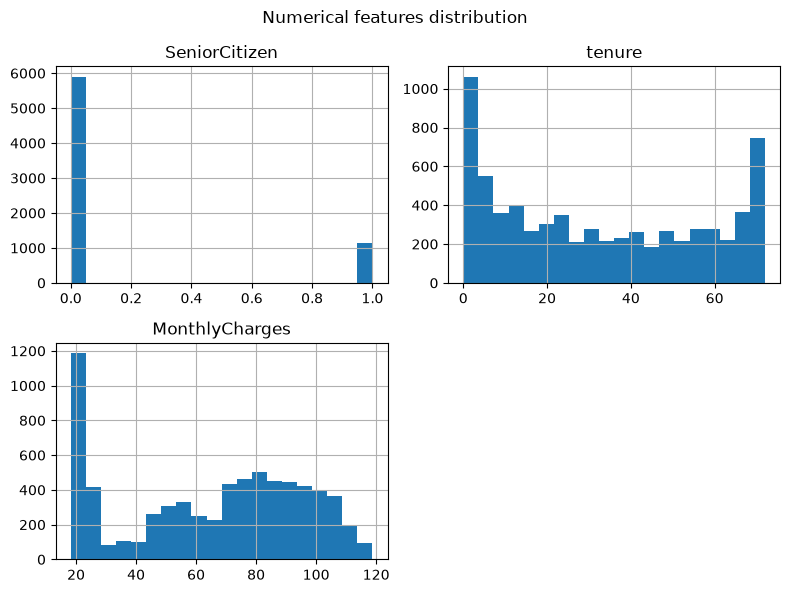

In [27]:
df[numerical_cols].hist(figsize=(8,6),bins = 20 )

plt.suptitle("Numerical features distribution")
plt.tight_layout()
plt.show()

##### Numerical features vs target class distributions:

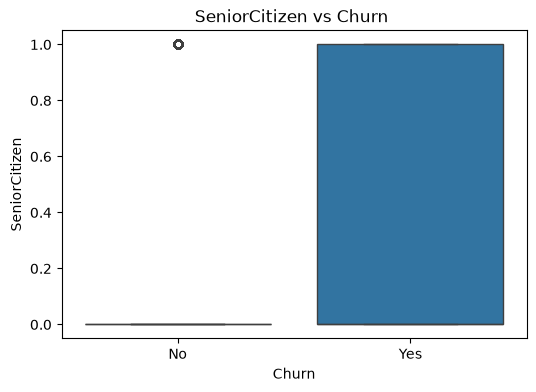

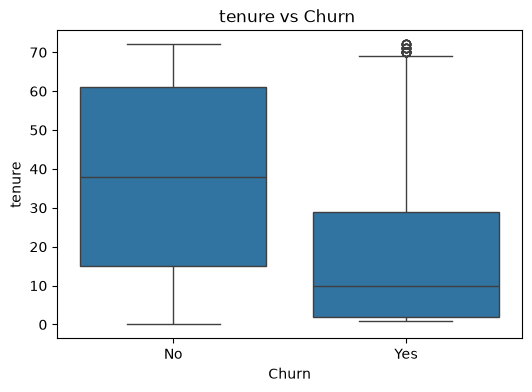

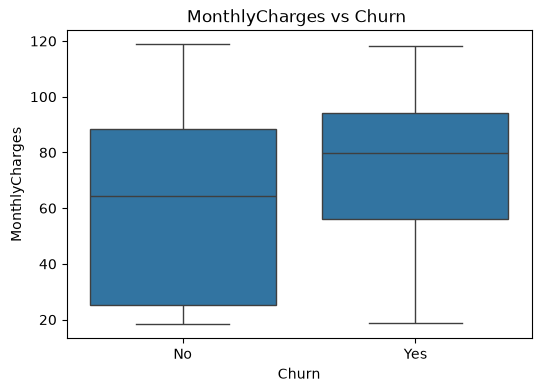

In [28]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    
    sns.boxplot(data = df, x = "Churn", y = col)
    
    plt.title(f"{col} vs Churn ")
    plt.show()

##### Categorical features vs target class distributions:

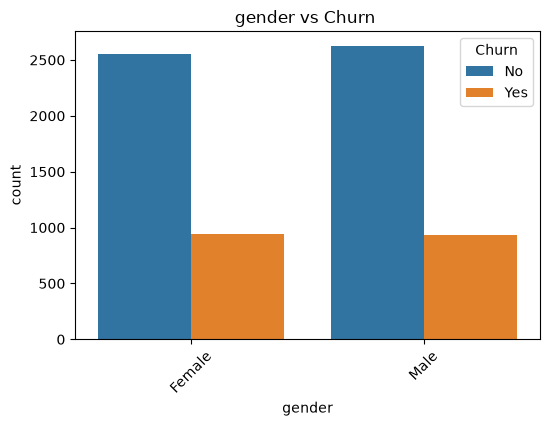

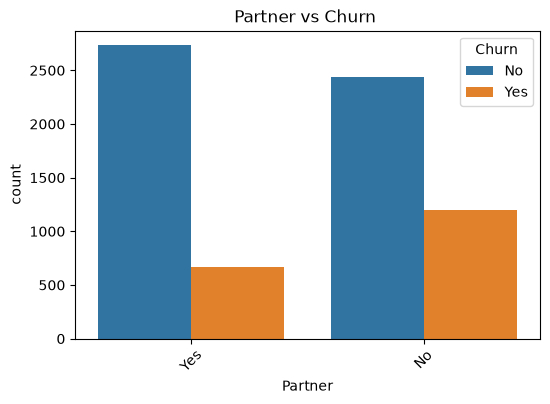

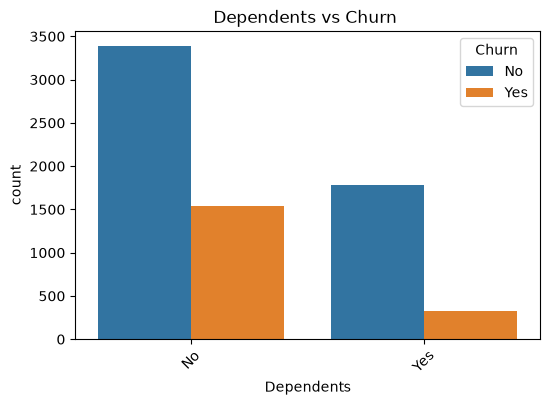

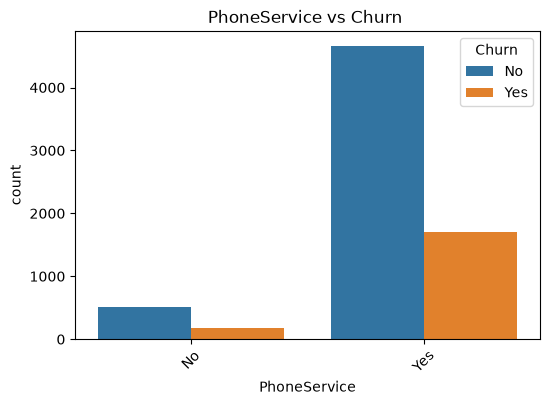

In [29]:
for col in categorical_cols[:4]: # 4 categorical features
    plt.figure(figsize=(6,4))
    
    sns.countplot(data = df, x = col, hue= "Churn")
    
    plt.title(f"{col} vs Churn ")
    plt.xticks(rotation=45)
    plt.show()

In [30]:
for col in categorical_cols[:6]: # 6 categorical features
    
    churn_rate = pd.crosstab(
        df[col],
        df["Churn"],
        normalize="index"
    )
    
    print(f"\n{col}")
    display(churn_rate)


gender


Churn,No,Yes
gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603



Partner


Churn,No,Yes
Partner,,
No,0.670420,0.329580
Yes,0.803351,0.196649



Dependents


...

Churn,No,Yes
PhoneService,,
No,0.750733,0.249267
Yes,0.732904,0.267096



MultipleLines


Churn,No,Yes
MultipleLines,,
No,0.749558,0.250442
No phone service,0.750733,0.249267
Yes,0.713901,0.286099



InternetService


Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


##### Correlation matrix:

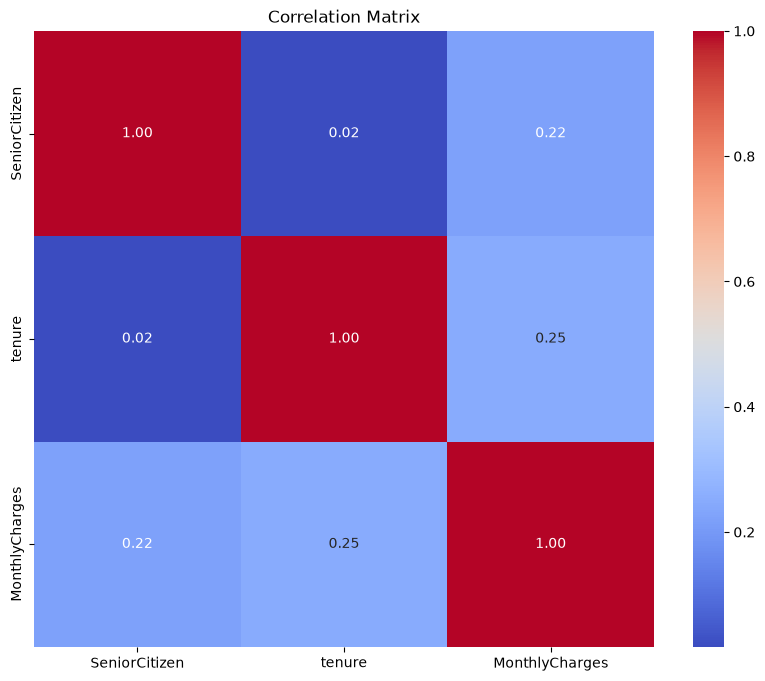

In [31]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

#### Base-line model:

In [32]:
preprocessor = ColumnTransformer([("num",
                                 StandardScaler(),
                                 numerical_cols)
                                 ,
                                ("col",
                                 OneHotEncoder(handle_unknown="ignore"),
                                 categorical_cols)
                                 ])

In [33]:
lr_pipe = Pipeline([ ("preprocessor", preprocessor)
                 ,
                  ("model", LogisticRegression(max_iter=1000, random_state=42) )])

In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_Scores = cross_val_score(lr_pipe, X_train, y_train ,cv=cv, scoring= "f1_macro", n_jobs=-1)

print(f1_Scores)
print("Mean F1 score: ",f1_Scores.mean())


acc_Scores = cross_val_score(lr_pipe, X_train, y_train ,cv=cv, scoring= "accuracy", n_jobs=-1)

print("")
print(acc_Scores)
print("Mean accuracy score: ",acc_Scores.mean())

[0.72533001 0.70020352 0.73522476 0.75336317 0.7312191 ]
Mean F1 score:  0.7290681124316563

[0.7985803  0.77905945 0.8065661  0.81188997 0.80728242]
Mean accuracy score:  0.8006756490533504


In [35]:
lr_pipe.fit(X_train,y_train)

lr_pred = lr_pipe.predict(X_test)

acc = accuracy_score(y_test,lr_pred)

print("TEST Accuracy score: ", acc)

TEST Accuracy score:  0.794180269694819
